# SD STEM Ecosystem — Opportunities Analysis

Analyzing **330 opportunities** extracted from the San Diego STEM Ecosystem website.

In [2]:
import json
from urllib.parse import urlparse
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

with open("data/opportunities.json") as f:
    data = json.load(f)

df = pd.DataFrame(data)
print(f"Total opportunities: {len(df)}")

Total opportunities: 330


## Top 10 Partners by Number of Opportunities

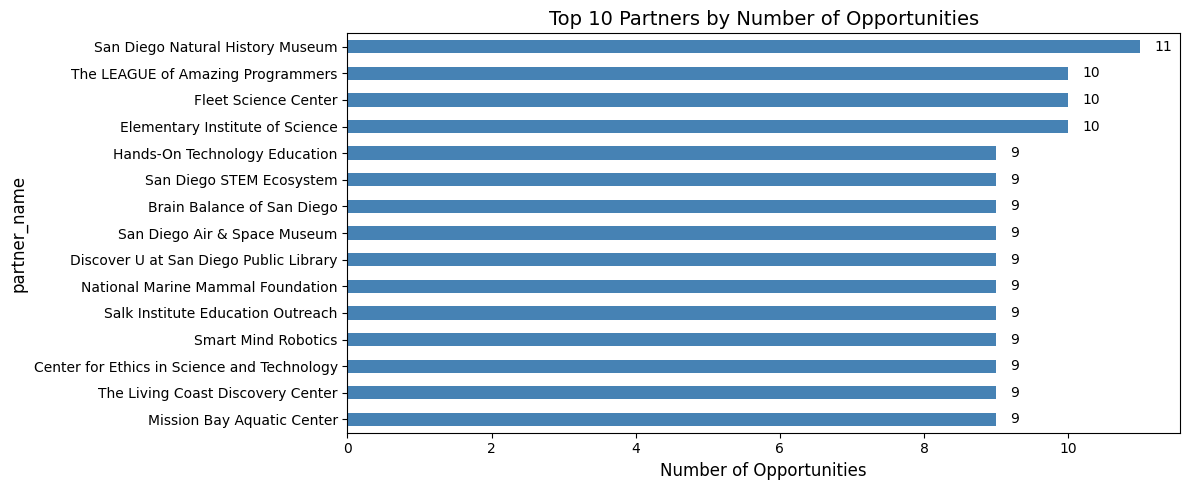


Unique partners: 98

Full counts:
partner_name
San Diego Natural History Museum                                         11
The LEAGUE of Amazing Programmers                                        10
Fleet Science Center                                                     10
Elementary Institute of Science                                          10
Hands-On Technology Education                                             9
San Diego STEM Ecosystem                                                  9
Brain Balance of San Diego                                                9
San Diego Air & Space Museum                                              9
Discover U at San Diego Public Library                                    9
National Marine Mammal Foundation                                         9
Salk Institute Education Outreach                                         9
Smart Mind Robotics                                                       9
Center for Ethics in Science and Technol

In [3]:
top_partners = df["partner_name"].value_counts().head(15)

fig, ax = plt.subplots()
top_partners.plot.barh(ax=ax, color="steelblue")
ax.invert_yaxis()
ax.set_xlabel("Number of Opportunities")
ax.set_title("Top 10 Partners by Number of Opportunities")
for i, v in enumerate(top_partners):
    ax.text(v + 0.2, i, str(v), va="center")
plt.tight_layout()
plt.show()

print(f"\nUnique partners: {df['partner_name'].nunique()}")
print(f"\nFull counts:\n{df['partner_name'].value_counts().to_string()}")

## Top 10 Link Domain Names

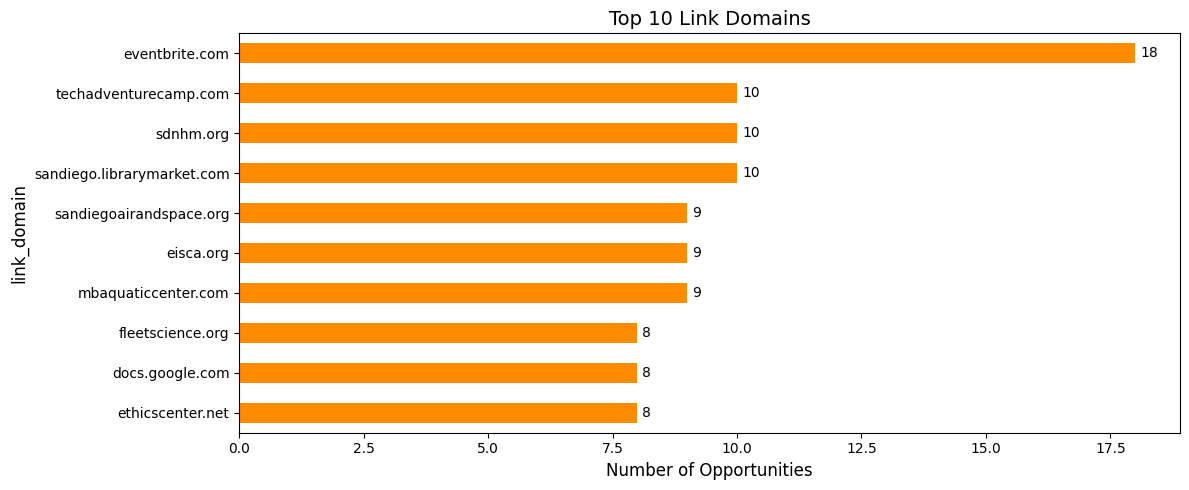


Unique link domains: 124


In [4]:
def extract_domain(url):
    if pd.isna(url):
        return None
    try:
        host = urlparse(url).netloc.lower()
        if host.startswith("www."):
            host = host[4:]
        return host or None
    except Exception:
        return None

df["link_domain"] = df["link"].apply(extract_domain)
top_domains = df["link_domain"].value_counts().head(10)

fig, ax = plt.subplots()
top_domains.plot.barh(ax=ax, color="darkorange")
ax.invert_yaxis()
ax.set_xlabel("Number of Opportunities")
ax.set_title("Top 10 Link Domains")
for i, v in enumerate(top_domains):
    ax.text(v + 0.1, i, str(v), va="center")
plt.tight_layout()
plt.show()

print(f"\nUnique link domains: {df['link_domain'].nunique()}")

## Opportunity Type (Online / In-Person / etc.)

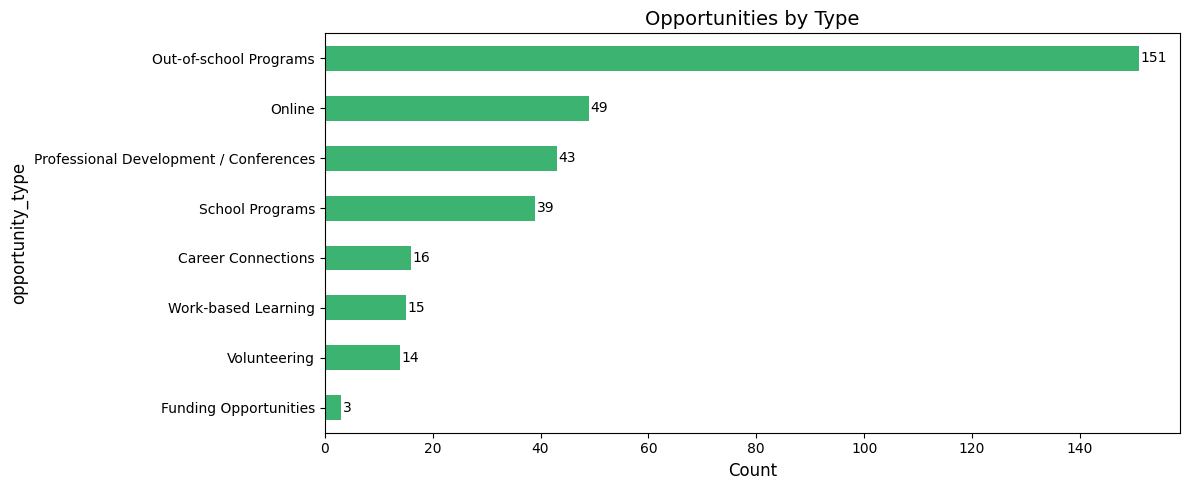

In [5]:
opp_type_counts = df["opportunity_type"].value_counts()

fig, ax = plt.subplots()
opp_type_counts.plot.barh(ax=ax, color="mediumseagreen")
ax.invert_yaxis()
ax.set_xlabel("Count")
ax.set_title("Opportunities by Type")
for i, v in enumerate(opp_type_counts):
    ax.text(v + 0.3, i, str(v), va="center")
plt.tight_layout()
plt.show()

## Cost Range — Free vs. Paid

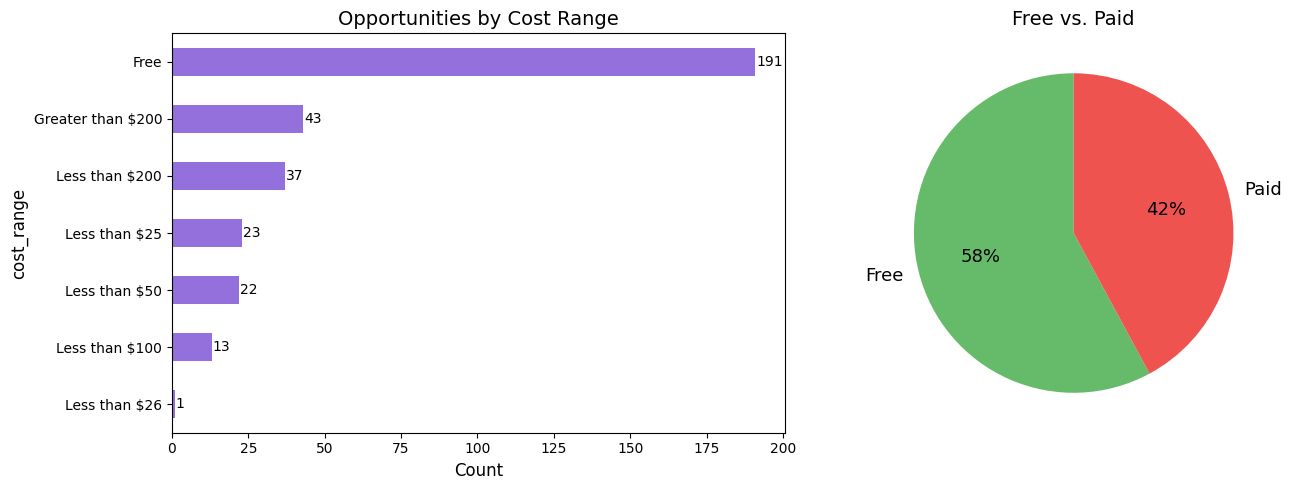

In [6]:
cost_counts = df["cost_range"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
cost_counts.plot.barh(ax=axes[0], color="mediumpurple")
axes[0].invert_yaxis()
axes[0].set_xlabel("Count")
axes[0].set_title("Opportunities by Cost Range")
for i, v in enumerate(cost_counts):
    axes[0].text(v + 0.3, i, str(v), va="center")

# Pie chart — Free vs Not Free
free_count = cost_counts.get("Free", 0)
paid_count = len(df) - free_count
pie_data = pd.Series({"Free": free_count, "Paid": paid_count})
axes[1].pie(pie_data, labels=pie_data.index, autopct="%1.0f%%",
            colors=["#66bb6a", "#ef5350"], startangle=90, textprops={"fontsize": 13})
axes[1].set_title("Free vs. Paid")

plt.tight_layout()
plt.show()

## Areas of Interest

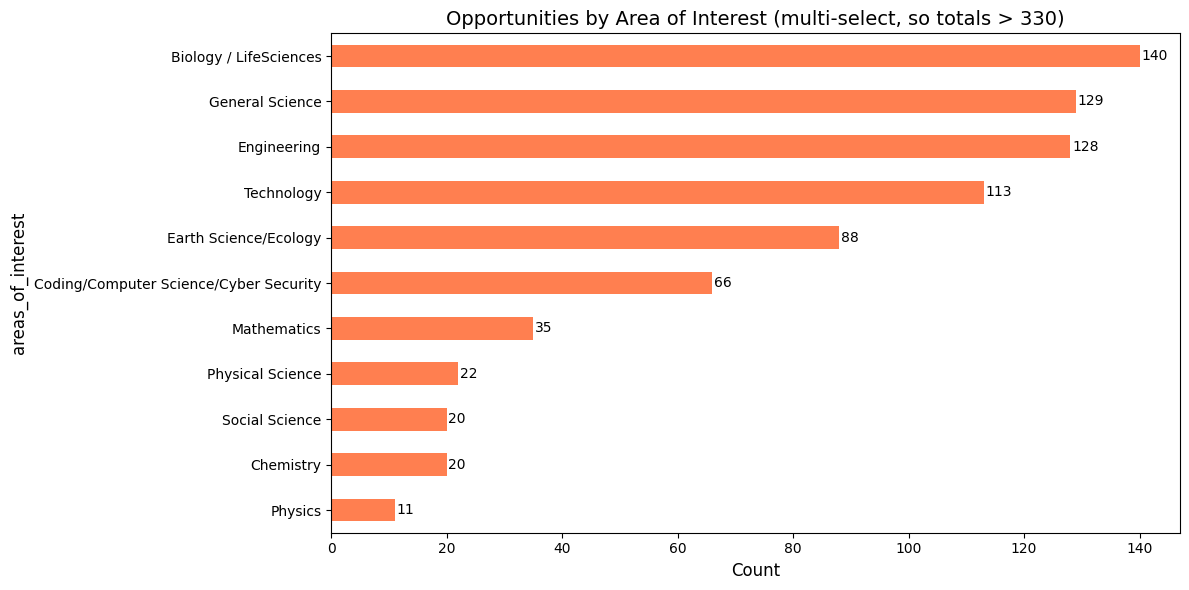

In [7]:
# Explode the multi-value areas_of_interest field
area_counts = df["areas_of_interest"].explode().value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
area_counts.plot.barh(ax=ax, color="coral")
ax.invert_yaxis()
ax.set_xlabel("Count")
ax.set_title("Opportunities by Area of Interest (multi-select, so totals > 330)")
for i, v in enumerate(area_counts):
    ax.text(v + 0.3, i, str(v), va="center")
plt.tight_layout()
plt.show()

## Top 10 Contact Email Domains

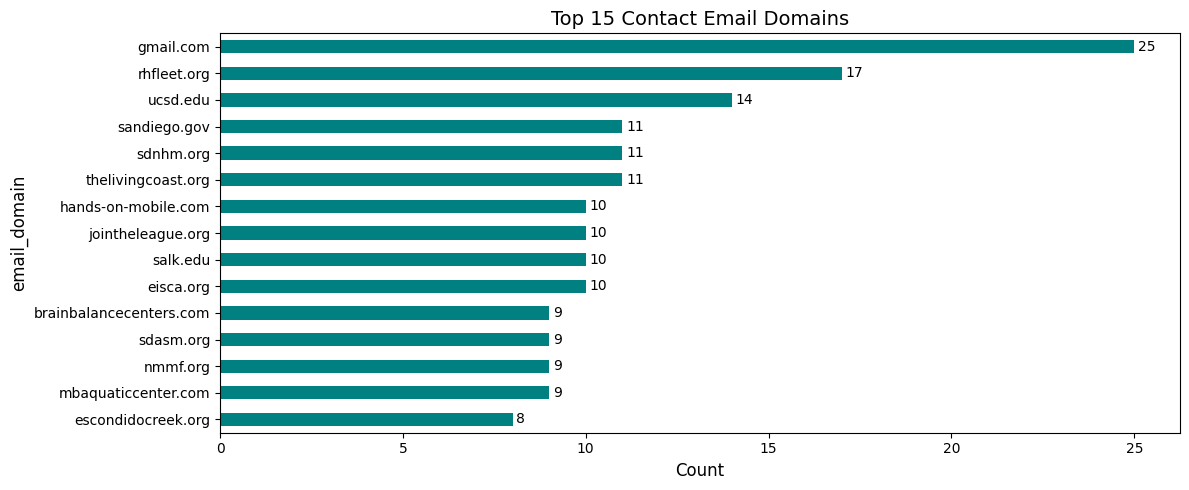


Unique email domains: 86


In [8]:
df["email_domain"] = df["contact_email"].str.split("@").str[-1].str.lower()
email_domain_counts = df["email_domain"].value_counts().head(15)

fig, ax = plt.subplots()
email_domain_counts.plot.barh(ax=ax, color="teal")
ax.invert_yaxis()
ax.set_xlabel("Count")
ax.set_title("Top 15 Contact Email Domains")
for i, v in enumerate(email_domain_counts):
    ax.text(v + 0.1, i, str(v), va="center")
plt.tight_layout()
plt.show()

print(f"\nUnique email domains: {df['email_domain'].nunique()}")

## Age / Grade Level & Time of Day

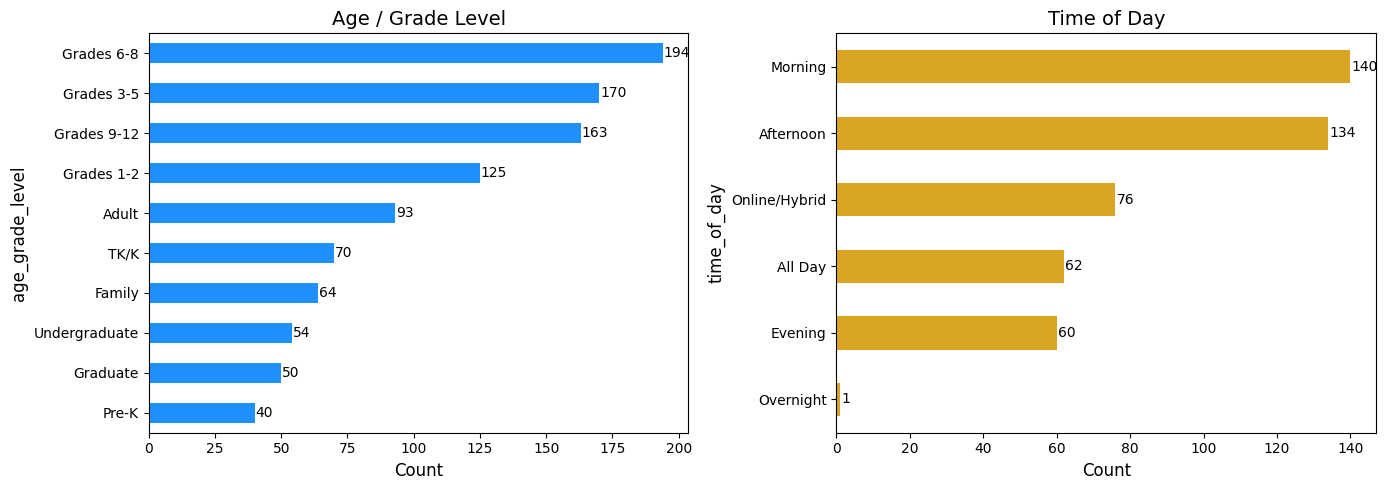

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age/Grade
grade_counts = df["age_grade_level"].explode().value_counts()
grade_counts.plot.barh(ax=axes[0], color="dodgerblue")
axes[0].invert_yaxis()
axes[0].set_xlabel("Count")
axes[0].set_title("Age / Grade Level")
for i, v in enumerate(grade_counts):
    axes[0].text(v + 0.3, i, str(v), va="center")

# Time of Day
tod_counts = df["time_of_day"].explode().value_counts()
tod_counts.plot.barh(ax=axes[1], color="goldenrod")
axes[1].invert_yaxis()
axes[1].set_xlabel("Count")
axes[1].set_title("Time of Day")
for i, v in enumerate(tod_counts):
    axes[1].text(v + 0.3, i, str(v), va="center")

plt.tight_layout()
plt.show()

## Financial Support & NGSS Alignment

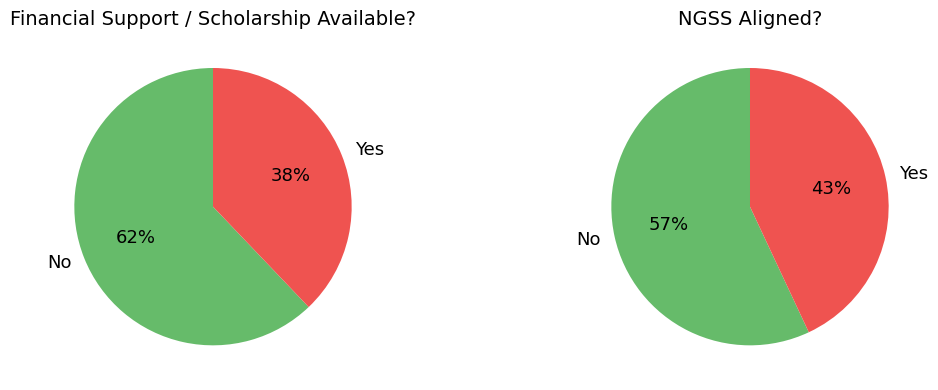

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ["#66bb6a", "#ef5350", "#90a4ae"]

for ax, col, title in [
    (axes[0], "financial_support", "Financial Support / Scholarship Available?"),
    (axes[1], "ngss_aligned", "NGSS Aligned?"),
]:
    counts = df[col].value_counts()
    ax.pie(counts, labels=counts.index, autopct="%1.0f%%",
           colors=colors[:len(counts)], startangle=90, textprops={"fontsize": 13})
    ax.set_title(title)

plt.tight_layout()
plt.show()

## Opportunities by Month

/tmp/ipykernel_112361/2570541702.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly = df.groupby(df["date_start_parsed"].dt.to_period("M")).size()


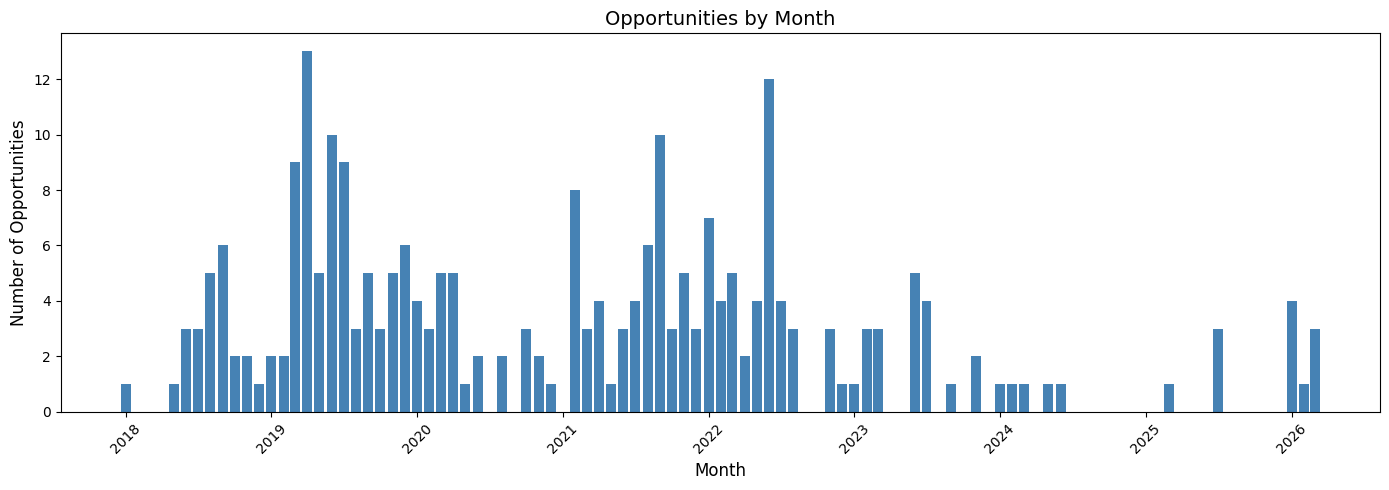

In [12]:
df["date_start_parsed"] = pd.to_datetime(df["date_start"], errors="coerce")

monthly = df.groupby(df["date_start_parsed"].dt.to_period("M")).size()
monthly.index = monthly.index.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(monthly.index, monthly.values, width=25, color="steelblue")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Opportunities")
ax.set_title("Opportunities by Month")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()